<a href="https://colab.research.google.com/github/ilyademichev1902/test/blob/main/NYC_crime_cleaning_feature%20selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [155]:
# prompt: attach google drive folder to read the dataset

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [157]:
# prompt: read csv file "cny.csv"

import pandas as pd

df = pd.read_csv('/content/drive/My Drive/datascience/NYPD_Complaint_Data_Current__Year_To_Date_.csv')
df.head()


<ipython-input-157-f3f630a2b77a>:5: DtypeWarning: Columns (0,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/My Drive/datascience/NYPD_Complaint_Data_Current__Year_To_Date_.csv')


,CMPLNT_NUM,ADDR_PCT_CD,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,HADEVELOPT,HOUSING_PSA,...,Latitude,Longitude,Lat_Lon,New Georeferenced Column,Unnamed: 36,CMPLNT_NUM.1,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41
0,282536052,79,BROOKLYN,2/15/2024,7:20:00,NaN,(null),COMPLETED,(null),NaN,...,40.689001,-73.945027,(40.68900139556,NaN,NaN,-282535894,-73.9450265328727);POINT (-73.9450265328727 4...,NaN,NaN,NaN
1,282805297,42,BRONX,2/25/2024,12:24:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,NaN,NaN,NaN,NaN,-282805213,SUBD 3,4,5;(null);02/25/2024;(null);18-24;BLACK;M;;45-6...,-73.894664);POINT (-73.894664 40.8288)
2,280611665,105,QUEENS,1/16/2024,8:00:00,1/16/2024,8:10:00,COMPLETED,(null),NaN,...,NaN,NaN,NaN,NaN,NaN,-280611455,SUBD 3,4,5;(null);01/16/2024;(null);65+;WHITE;F;;65+;WH...,-73.716036);POINT (-73.716036 40.731173)
3,284354345,68,BROOKLYN,3/25/2024,11:16:00,3/25/2024,16:00:00,COMPLETED,(null),NaN,...,NaN,NaN,NaN,NaN,NaN,-284354209,CRIMINAL 4,OF MOTOR;STREET;03/26/2024;(null);(null);(nul...,-74.013008);POINT (-74.013008 40.633899),NaN
4,282082987,17,MANHATTAN,02.12.2024,12:35:00,02.12.2024,12:40:00,COMPLETED,(null),NaN,...,NaN,NaN,NaN,NaN,NaN,-282082953,PETIT FROM OPEN AREAS,;STREET;02.12.2024;(null);25-44;BLACK;F;;UNKNO...,-73.971465);POINT (-73.971465 40.752848),NaN


In [158]:
# prompt: print number of rows in df dataframe

print("Rows total:",len(df))


Rows total: 137270


In [161]:
# prompt: replace values of (null) by NaN in df dataset
print("Before replacing\nAmount of missed values:\n")
print(df.isna().sum())
#df.head()


Before replacing
Amount of missed values:

CMPLNT_NUM                       0
ADDR_PCT_CD                      0
BORO_NM                          0
CMPLNT_FR_DT                     0
CMPLNT_FR_TM                     0
CMPLNT_TO_DT                  7240
CMPLNT_TO_TM                     0
CRM_ATPT_CPTD_CD                 0
HADEVELOPT                       0
HOUSING_PSA                 128581
JURISDICTION_CODE                0
JURIS_DESC                       0
KY_CD                            0
LAW_CAT_CD                       0
LOC_OF_OCCUR_DESC                0
OFNS_DESC                        0
PARKS_NM                         6
PATROL_BORO                      6
PD_CD                           93
PD_DESC                          6
PREM_TYP_DESC               108179
RPT_DT                      108179
STATION_NAME                108179
SUSP_AGE_GROUP              108179
SUSP_RACE                   108179
SUSP_SEX                    108179
TRANSIT_DISTRICT            135946
VIC_AGE_GROU

In [162]:
#replace text nulls
df.replace('(null)', pd.NA, inplace=True)



In [164]:
#replace text NaNs
df.replace('NaN', pd.NA, inplace=True)
print("After text null and Nan replacing into pandas.NaN:")
print(df.isna().sum())


After text null and Nan replacing into pandas.NaN:
CMPLNT_NUM                       0
ADDR_PCT_CD                      0
BORO_NM                          7
CMPLNT_FR_DT                     0
CMPLNT_FR_TM                     0
CMPLNT_TO_DT                  7240
CMPLNT_TO_TM                  7129
CRM_ATPT_CPTD_CD                 0
HADEVELOPT                  136867
HOUSING_PSA                 128581
JURISDICTION_CODE                0
JURIS_DESC                       0
KY_CD                            0
LAW_CAT_CD                       0
LOC_OF_OCCUR_DESC            28935
OFNS_DESC                        3
PARKS_NM                    136816
PATROL_BORO                      6
PD_CD                           93
PD_DESC                         93
PREM_TYP_DESC               110024
RPT_DT                      108179
STATION_NAME                135946
SUSP_AGE_GROUP              109671
SUSP_RACE                   109671
SUSP_SEX                    109671
TRANSIT_DISTRICT            135946
VIC_

In [171]:
# prompt: list columns by index
threshold = 60
threshold_number = int(len(df) * threshold/100)
print("\n".join([str(num)+":"+str(col)+" missing" if int(col)>threshold_number else str(num)+":"+">"+str(threshold)+"% present" for num,col in enumerate(df.isnull().sum())]))


0:>60% present
1:>60% present
2:>60% present
3:>60% present
4:>60% present
5:>60% present
6:>60% present
7:>60% present
8:>60% present
9:>60% present
10:>60% present
11:>60% present
12:>60% present
13:>60% present
14:>60% present
15:>60% present
16:>60% present
17:110024 missing
18:108179 missing
19:135946 missing
20:>60% present
21:90721 missing


In [172]:
# prompt: eliminate from df dataframe columns 35 and 36

#df = df.drop(df.columns[[8,9,16, 41]], axis=1)
#df = df.drop(df.columns[list(range(20,36))], axis=1)
df = df.drop(df.columns[[17,18,19,21]], axis=1)

In [63]:
# prompt: eliminate TRANSIT_DISTRICT column

#df = df.drop('TRANSIT_DISTRICT', axis=1)
#df = df.drop('STATION_NAME', axis=1)
#print("After dropping missed and 95% missed columns:",df.isnull().sum())

In [173]:
#df.dropna(inplace=True)
#df = df.drop('Unnamed: 40', axis=1)
print("After dropping columns with less than {}% data present ,still missing".format(threshold))
print(df.isna().sum())

After dropping columns with less than 60% data present ,still missing
CMPLNT_NUM               0
ADDR_PCT_CD              0
BORO_NM                  7
CMPLNT_FR_DT             0
CMPLNT_FR_TM             0
CMPLNT_TO_DT          7240
CMPLNT_TO_TM          7129
CRM_ATPT_CPTD_CD         0
JURISDICTION_CODE        0
JURIS_DESC               0
KY_CD                    0
LAW_CAT_CD               0
LOC_OF_OCCUR_DESC    28935
OFNS_DESC                3
PATROL_BORO              6
PD_CD                   93
PD_DESC                 93
Unnamed: 39          29091
dtype: int64


In [174]:
#print("Rows total:",len(df))
df.head()

,CMPLNT_NUM,ADDR_PCT_CD,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,JURISDICTION_CODE,JURIS_DESC,KY_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC,PATROL_BORO,PD_CD,PD_DESC,Unnamed: 39
0,282536052,79,BROOKLYN,2/15/2024,7:20:00,NaN,<NA>,COMPLETED,0,N.Y. POLICE DEPT,104,FELONY,INSIDE,RAPE,PATROL BORO BKLYN NORTH,153.0,RAPE 3,NaN
1,282805297,42,BRONX,2/25/2024,12:24:00,NaN,<NA>,COMPLETED,0,N.Y. POLICE DEPT,578,VIOLATION,INSIDE,HARRASSMENT 2,PATROL BORO BRONX,638.0,HARASSMENT,4
2,280611665,105,QUEENS,1/16/2024,8:00:00,1/16/2024,8:10:00,COMPLETED,0,N.Y. POLICE DEPT,578,VIOLATION,FRONT OF,HARRASSMENT 2,PATROL BORO QUEENS SOUTH,638.0,HARASSMENT,4
3,284354345,68,BROOKLYN,3/25/2024,11:16:00,3/25/2024,16:00:00,COMPLETED,0,N.Y. POLICE DEPT,351,MISDEMEANOR,FRONT OF,CRIMINAL MISCHIEF & RELATED OF,PATROL BORO BKLYN SOUTH,254.0,MISCHIEF,OF MOTOR;STREET;03/26/2024;(null);(null);(nul...
4,282082987,17,MANHATTAN,02.12.2024,12:35:00,02.12.2024,12:40:00,COMPLETED,0,N.Y. POLICE DEPT,341,MISDEMEANOR,FRONT OF,PETIT LARCENY,PATROL BORO MAN SOUTH,339.0,LARCENY,;STREET;02.12.2024;(null);25-44;BLACK;F;;UNKNO...


In [176]:
# prompt: replace numpy NaN with pandas NaN , drop rows that contain pandas NaN

import numpy as np

# Replace numpy NaN with pandas NaN
df.replace(np.nan, pd.NA, inplace=True)
df.head()
# Drop rows with pandas NaN
before_dropna = df.copy(deep=True)
df.dropna(inplace=True)


In [180]:
print("After dropping all the rest of missing values".format(threshold))
print(df.isna().sum())


After dropping all the rest of missing values
CMPLNT_NUM           0
ADDR_PCT_CD          0
BORO_NM              0
CMPLNT_FR_DT         0
CMPLNT_FR_TM         0
CMPLNT_TO_DT         0
CMPLNT_TO_TM         0
CRM_ATPT_CPTD_CD     0
JURISDICTION_CODE    0
JURIS_DESC           0
KY_CD                0
LAW_CAT_CD           0
LOC_OF_OCCUR_DESC    0
OFNS_DESC            0
PATROL_BORO          0
PD_CD                0
PD_DESC              0
Unnamed: 39          0
dtype: int64


In [181]:
print("Data rows left")
print(len(df))

Data rows left
81885


In [182]:
# prompt: find unique values of field JURISDICTION_CODE and number of each of them

unique_values = df['JURISDICTION_CODE'].value_counts()
print(unique_values)


JURISDICTION_CODE
0     75196
2      5876
3       257
17      192
97      132
72      104
51       29
87       24
7        17
73       16
14       12
88        9
4         9
11        5
52        4
12        1
76        1
13        1
Name: count, dtype: int64


In [183]:
# prompt: print the datatype for each column

print(df.dtypes)


CMPLNT_NUM           object
ADDR_PCT_CD           int64
BORO_NM              object
CMPLNT_FR_DT         object
CMPLNT_FR_TM         object
CMPLNT_TO_DT         object
CMPLNT_TO_TM         object
CRM_ATPT_CPTD_CD     object
JURISDICTION_CODE     int64
JURIS_DESC           object
KY_CD                 int64
LAW_CAT_CD           object
LOC_OF_OCCUR_DESC    object
OFNS_DESC            object
PATROL_BORO          object
PD_CD                object
PD_DESC              object
Unnamed: 39          object
dtype: object


In [184]:
#print amount of unique values for each column
print("Unnique values for each column\n")
print(df.nunique())

Unnique values for each column

CMPLNT_NUM           81885
ADDR_PCT_CD             77
BORO_NM                  5
CMPLNT_FR_DT           809
CMPLNT_FR_TM          1439
CMPLNT_TO_DT           574
CMPLNT_TO_TM          1440
CRM_ATPT_CPTD_CD         2
JURISDICTION_CODE       18
JURIS_DESC              18
KY_CD                   51
LAW_CAT_CD               3
LOC_OF_OCCUR_DESC        4
OFNS_DESC               43
PATROL_BORO              8
PD_CD                  226
PD_DESC                 78
Unnamed: 39          38466
dtype: int64


In [190]:
# prompt: drop columns from ['JURISDICTION_CODE', 'PD_CD','CMPLNT_NUM','KY_CD'] if exist
# display the head

# Drop columns if they exist
for col in ['JURISDICTION_CODE', 'PD_CD','CMPLNT_NUM','KY_CD','ADDR_PCT_CD','PATROL_BORO','JURIS_DESC']:
  if col in df.columns:
    df = df.drop(col, axis=1)



SyntaxError: invalid syntax (<ipython-input-190-cf047e82df0b>, line 10)

In [192]:
# prompt: drop last colum

df = df.iloc[:, :-1]

# Display the head

df.head()


,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC
2,QUEENS,1/16/2024,8:00:00,1/16/2024,8:10:00,COMPLETED,VIOLATION,FRONT OF,HARRASSMENT 2
3,BROOKLYN,3/25/2024,11:16:00,3/25/2024,16:00:00,COMPLETED,MISDEMEANOR,FRONT OF,CRIMINAL MISCHIEF & RELATED OF
4,MANHATTAN,02.12.2024,12:35:00,02.12.2024,12:40:00,COMPLETED,MISDEMEANOR,FRONT OF,PETIT LARCENY
6,STATEN ISLAND,02.07.2024,14:05:00,02.07.2024,14:05:00,COMPLETED,MISDEMEANOR,FRONT OF,OFFENSES AGAINST PUBLIC ADMINI
8,BROOKLYN,2/22/2024,15:30:00,2/22/2024,15:40:00,COMPLETED,FELONY,INSIDE,GRAND LARCENY


In [193]:
# prompt: number of unique values for each column , display unique values if amount is less than 5
categorical = {}
for col in df.columns:
  unique_vals = df[col].unique()
  num_unique = len(unique_vals)
  #print(f"Column '{col}': {num_unique} unique values")
  if num_unique <= 5:
    categorical[col] = unique_vals
    #print(f"{col}:15: {unique_vals}")


In [194]:
# prompt:  print a dictionary categorical in a  table , each column with increasing number of values

import pandas as pd

# Create a DataFrame from the dictionary
df_categorical = pd.DataFrame.from_dict(categorical, orient='index').transpose()

# Sort columns by the number of unique values
df_categorical = df_categorical.reindex(sorted(df_categorical.columns, key=lambda col: df_categorical[col].nunique()), axis=1)

# Display the DataFrame as a table
print(df_categorical)


  CRM_ATPT_CPTD_CD   LAW_CAT_CD LOC_OF_OCCUR_DESC        BORO_NM
0        COMPLETED    VIOLATION          FRONT OF         QUEENS
1        ATTEMPTED  MISDEMEANOR            INSIDE       BROOKLYN
2             None       FELONY           REAR OF      MANHATTAN
3             None         None       OPPOSITE OF  STATEN ISLAND
4             None         None              None          BRONX


In [195]:
before_labeling = df.copy(deep=True)

In [196]:
# prompt: apply labelencoder only for columns from categorical keys

from sklearn.preprocessing import LabelEncoder

# Apply LabelEncoder to categorical columns
label_encoder = LabelEncoder()
for col in categorical.keys():
  df[col] = label_encoder.fit_transform(df[col])

# Display the head of the DataFrame
df.head()


,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC
2,3,1/16/2024,8:00:00,1/16/2024,8:10:00,1,2,0,HARRASSMENT 2
3,1,3/25/2024,11:16:00,3/25/2024,16:00:00,1,1,0,CRIMINAL MISCHIEF & RELATED OF
4,2,02.12.2024,12:35:00,02.12.2024,12:40:00,1,1,0,PETIT LARCENY
6,4,02.07.2024,14:05:00,02.07.2024,14:05:00,1,1,0,OFFENSES AGAINST PUBLIC ADMINI
8,1,2/22/2024,15:30:00,2/22/2024,15:40:00,1,0,1,GRAND LARCENY


In [197]:
before_time_removal = df.copy(deep=True)
#eliminate time
for col in ['CMPLNT_FR_DT', 'CMPLNT_FR_TM','CMPLNT_TO_DT','CMPLNT_TO_TM']:
  if col in df.columns:
    df = df.drop(col, axis=1)

In [198]:
df.head()

,BORO_NM,CRM_ATPT_CPTD_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC
2,3,1,2,0,HARRASSMENT 2
3,1,1,1,0,CRIMINAL MISCHIEF & RELATED OF
4,2,1,1,0,PETIT LARCENY
6,4,1,1,0,OFFENSES AGAINST PUBLIC ADMINI
8,1,1,0,1,GRAND LARCENY


In [199]:
# prompt:   encode OFNS_DESC with labelencoder specify CRM_ATPT_CPTD_CD as a target variable and others as predictors

# Apply LabelEncoder to 'OFNS_DESC'
label_encoder = LabelEncoder()
df['OFNS_DESC'] = label_encoder.fit_transform(df['OFNS_DESC'])



In [201]:
df.head()

,BORO_NM,CRM_ATPT_CPTD_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC
2,3,1,2,0,19
3,1,1,1,0,6
4,2,1,1,0,34
6,4,1,1,0,26
8,1,1,0,1,17


In [202]:
# Specify target variable and predictors
X = df.drop('CRM_ATPT_CPTD_CD', axis=1)  # Predictors
y = df['CRM_ATPT_CPTD_CD']  # Target variable

In [203]:
X.head()

,BORO_NM,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC
2,3,2,0,19
3,1,1,0,6
4,2,1,0,34
6,4,1,0,26
8,1,0,1,17


In [207]:
# prompt: count amount of each unique value for y

unique_values_count = y.value_counts()
print(unique_values_count)


CRM_ATPT_CPTD_CD
1    80553
0     1332
Name: count, dtype: int64


# Highly biased dataset

In [208]:
LinearSVC# prompt: count amount of each unique value for each column in X

# Count amount of each unique value for each column in X
for col in X.columns:
  unique_values_count = X[col].value_counts()
  print(f"Unique values count for column '{col}':\n{unique_values_count}\n")


Unique values count for column 'BORO_NM':
BORO_NM
1    22390
2    21192
3    18760
0    15645
4     3898
Name: count, dtype: int64

Unique values count for column 'LAW_CAT_CD':
LAW_CAT_CD
1    36800
0    27857
2    17228
Name: count, dtype: int64

Unique values count for column 'LOC_OF_OCCUR_DESC':
LOC_OF_OCCUR_DESC
1    54115
0    24232
2     2116
3     1422
Name: count, dtype: int64

Unique values count for column 'OFNS_DESC':
OFNS_DESC
34    23424
19    17085
17     9675
6      7120
12     3822
4      2993
39     2911
18     2569
2      2045
8      1859
40     1610
42      837
7       747
41      722
13      640
26      548
14      487
31      364
36      323
23      317
9       301
29      246
20      237
1       148
0       142
24      119
33      110
35      103
3        88
25       84
5        48
28       45
16       36
38       22
22       14
37       13
27       11
32        7
11        6
10        4
15        1
21        1
30        1
Name: count, dtype: int64



In [213]:
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel

print("before LinearSVC:")
print(X.shape)
lsvc = LinearSVC(C=0.01, penalty="l1", dual=False).fit(X, y)
model = SelectFromModel(lsvc, prefit=True)
X_new = model.transform(X)
print("after LinearSVC:")
print(X_new.shape)

before LinearSVC:
(81885, 4)
after LinearSVC:
(81885, 4)


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:458: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [215]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectFromModel
#X, y = load_iris(return_X_y=True)
print("before ExtraTreesClassifier:")
print(X.shape)
clf = ExtraTreesClassifier(n_estimators=50)
clf = clf.fit(X, y)
clf.feature_importances_
model = SelectFromModel(clf, prefit=True)
X_new = model.transform(X)
print("After ExtraTreesClassifier")
print(X_new.shape)

before ExtraTreesClassifier:
(81885, 4)
After ExtraTreesClassifier
(81885, 1)


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:458: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [217]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
#X, y = load_iris(return_X_y=True)
print(X.shape)
X_new = SelectKBest(f_classif, k=2).fit_transform(X, y)
print(X_new.shape)

(81885, 4)
(81885, 2)


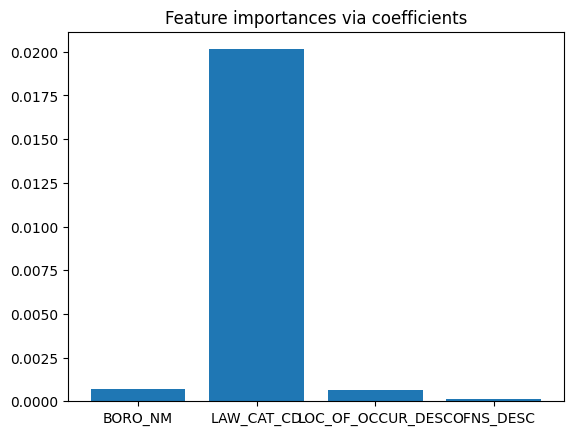

In [222]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=np.logspace(-6, 6, num=5)).fit(X, y)
importance = np.abs(ridge.coef_)
feature_names = np.array(X.columns)
plt.bar(height=importance, x=feature_names)
plt.title("Feature importances via coefficients")
plt.show()

In [225]:
num_of_features = 2

from sklearn.feature_selection import SequentialFeatureSelector
from time import time
tic_fwd = time()
sfs_forward = SequentialFeatureSelector(
    ridge, n_features_to_select=num_of_features , direction="forward"
).fit(X, y)
toc_fwd = time()

tic_bwd = time()
sfs_backward = SequentialFeatureSelector(
    ridge, n_features_to_select=num_of_features, direction="backward"
).fit(X, y)
toc_bwd = time()

print(
    "Features selected by forward sequential selection: "
    f"{feature_names[sfs_forward.get_support()]}"
)
print(f"Done in {toc_fwd - tic_fwd:.3f}s")
print(
    "Features selected by backward sequential selection: "
    f"{feature_names[sfs_backward.get_support()]}"
)
print(f"Done in {toc_bwd - tic_bwd:.3f}s")

Features selected by forward sequential selection: ['LAW_CAT_CD' 'LOC_OF_OCCUR_DESC']
Done in 2.056s
Features selected by backward sequential selection: ['LAW_CAT_CD' 'LOC_OF_OCCUR_DESC']
Done in 2.927s
